In [1]:
import fastf1
import pandas as pd

In [2]:
fastf1.Cache.enable_cache('../data')

In [5]:
session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

In [6]:
laps =session.laps

In [7]:
laps.shape

(1007, 31)

In [8]:
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,...,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True


In [9]:
laps.to_csv('../data/australian_gp_laps.csv',index = "False")

In [10]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [11]:
for driver in laps['Driver'].unique():print(driver)

NOR
GAS
PER
ANT
ALO
LEC
STR
ALB
HUL
VER
LAW
OCO
LIN
COL
HAM
BOR
SAI
HAD
RUS
BOT
BEA


In [12]:
laps_clean =laps.copy()

In [13]:
laps_clean.isnull().sum()

Time                    0
Driver                  0
DriverNumber            0
LapTime                 7
LapNumber               0
Stint                   0
PitOutTime            975
PitInTime             974
Sector1Time            23
Sector2Time             3
Sector3Time             6
Sector1SessionTime     27
Sector2SessionTime      3
Sector3SessionTime      6
SpeedI1                 3
SpeedI2                 3
SpeedFL                36
SpeedST                 3
IsPersonalBest          2
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            2
TrackStatus             0
Position                3
Deleted                 0
DeletedReason           2
FastF1Generated         0
IsAccurate              0
dtype: int64

In [14]:
laps_clean = laps_clean.dropna(subset=['Driver','LapNumber','LapTime'])

In [15]:
laps_clean['LapTimeSeconds'] = laps_clean['LapTime'].dt.total_seconds()

In [16]:
laps_clean[['Driver','LapTimeSeconds']].head()

,Driver,LapTimeSeconds
0,NOR,96.458
1,NOR,87.344
2,NOR,86.863
3,NOR,85.857
4,NOR,85.573


In [17]:
laps_filtered = laps_clean.copy()

laps_filtered = laps_filtered[
    (laps_filtered['IsAccurate'] == True) &
    (laps_filtered['Deleted'] == False)
]

laps_filtered = laps_filtered[
    (laps_filtered['PitInTime'].isna()) &
    (laps_filtered['PitOutTime'].isna())
]

laps_filtered['LapTimeSeconds'] = laps_filtered['LapTime'].dt.total_seconds()

laps_filtered = laps_filtered[
    (laps_filtered['LapTimeSeconds'] > 80) &
    (laps_filtered['LapTimeSeconds'] < 95)
]

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))  # width, height

<Figure size 2000x800 with 0 Axes>

<Figure size 2000x800 with 0 Axes>

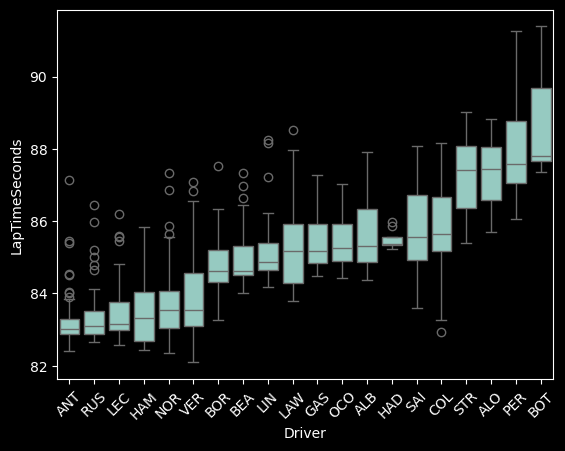

<Figure size 640x480 with 0 Axes>

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt

order = laps_filtered.groupby('Driver')['LapTimeSeconds'] \
                     .median() \
                     .sort_values() \
                     .index

# plot
sns.boxplot(
    data=laps_filtered,
    x='Driver',
    y='LapTimeSeconds',
    order=order
)

plt.xticks(rotation=45)
plt.show()
plt.savefig('../outputs/race_pace_boxplot.png')

In [34]:
laps_clean['LapTimeSeconds'].describe()

count    1000.000000
mean       88.065685
std         8.316121
min        82.091000
25%        84.013000
50%        85.224500
75%        87.219000
max       132.251000
Name: LapTimeSeconds, dtype: float64

In [35]:
laps_filtered.groupby('Driver')['LapTimeSeconds'].median().sort_values()

Driver
ANT    83.0170
RUS    83.0900
LEC    83.1670
HAM    83.3135
NOR    83.5340
VER    83.5345
BOR    84.6210
BEA    84.6270
LIN    84.8625
LAW    85.1675
GAS    85.1895
OCO    85.2490
ALB    85.3155
HAD    85.3630
SAI    85.5645
COL    85.6330
STR    87.4160
ALO    87.4495
PER    87.5950
BOT    87.8040
Name: LapTimeSeconds, dtype: float64

In [36]:
laps_filtered['CumulativeTime'] = laps_filtered.groupby('Driver')['LapTimeSeconds'].cumsum()

In [37]:
laps_filtered['CumulativeTime'].head()

1     87.344
2    174.207
3    260.064
4    345.637
5    430.673
Name: CumulativeTime, dtype: float64

In [43]:
leader_time = laps_filtered.groupby('LapNumber')['CumulativeTime'].min()

In [45]:
leader_time.head()

LapNumber
2.0     84.626
3.0    169.500
4.0    254.566
5.0    339.068
6.0    345.535
Name: CumulativeTime, dtype: float64

In [47]:
laps_filtered['GapToLeader'] = laps_filtered['CumulativeTime'] - laps_filtered['LapNumber'].map(leader_time)

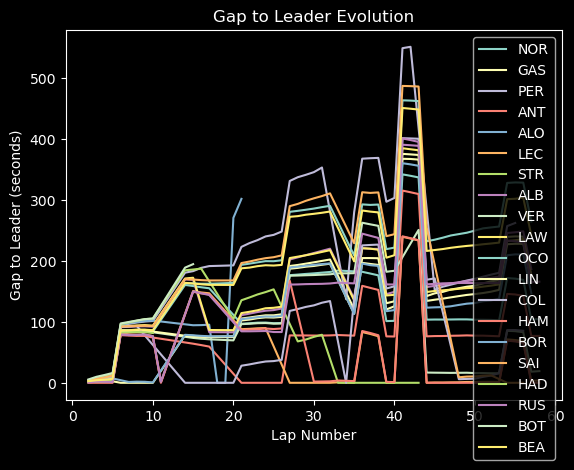

<Figure size 640x480 with 0 Axes>

In [255]:
import matplotlib.pyplot as plt

for driver in laps_filtered['Driver'].unique():
    driver_data = laps_filtered[laps_filtered['Driver'] == driver]
    plt.plot(driver_data['LapNumber'], driver_data['GapToLeader'], label=driver)

plt.xlabel("Lap Number")
plt.ylabel("Gap to Leader (seconds)")
plt.title("Gap to Leader Evolution")

plt.legend()
plt.show()
plt.savefig('../outputs/gap_to_leader.png')

In [50]:
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

In [53]:
laps['CumulativeTime'] = laps.groupby('Driver')['LapTimeSeconds'].cumsum()

In [249]:
final_positions = laps.groupby('Driver').tail(1)
final_positions = final_positions.sort_values('CumulativeTime')

final_positions[['Driver','CumulativeTime']]


KeyError: 'CumulativeTime'

In [57]:
fastest_laps = laps_clean.sort_values('LapTimeSeconds')

In [59]:
top20 = fastest_laps.head(20)

In [253]:
top20[['Driver','LapTimeSeconds','LapNumber','Compound','TyreLife']]


,Driver,LapTimeSeconds,LapNumber,Compound,TyreLife
451,VER,82.091,43.0,HARD,2.0
52,NOR,82.358,53.0,MEDIUM,19.0
226,ANT,82.417,57.0,HARD,45.0
748,HAM,82.423,55.0,HARD,27.0
453,VER,82.453,45.0,HARD,4.0
455,VER,82.489,47.0,HARD,6.0
749,HAM,82.500,56.0,HARD,28.0
452,VER,82.520,44.0,HARD,3.0
738,HAM,82.529,45.0,HARD,17.0
732,HAM,82.536,39.0,HARD,11.0


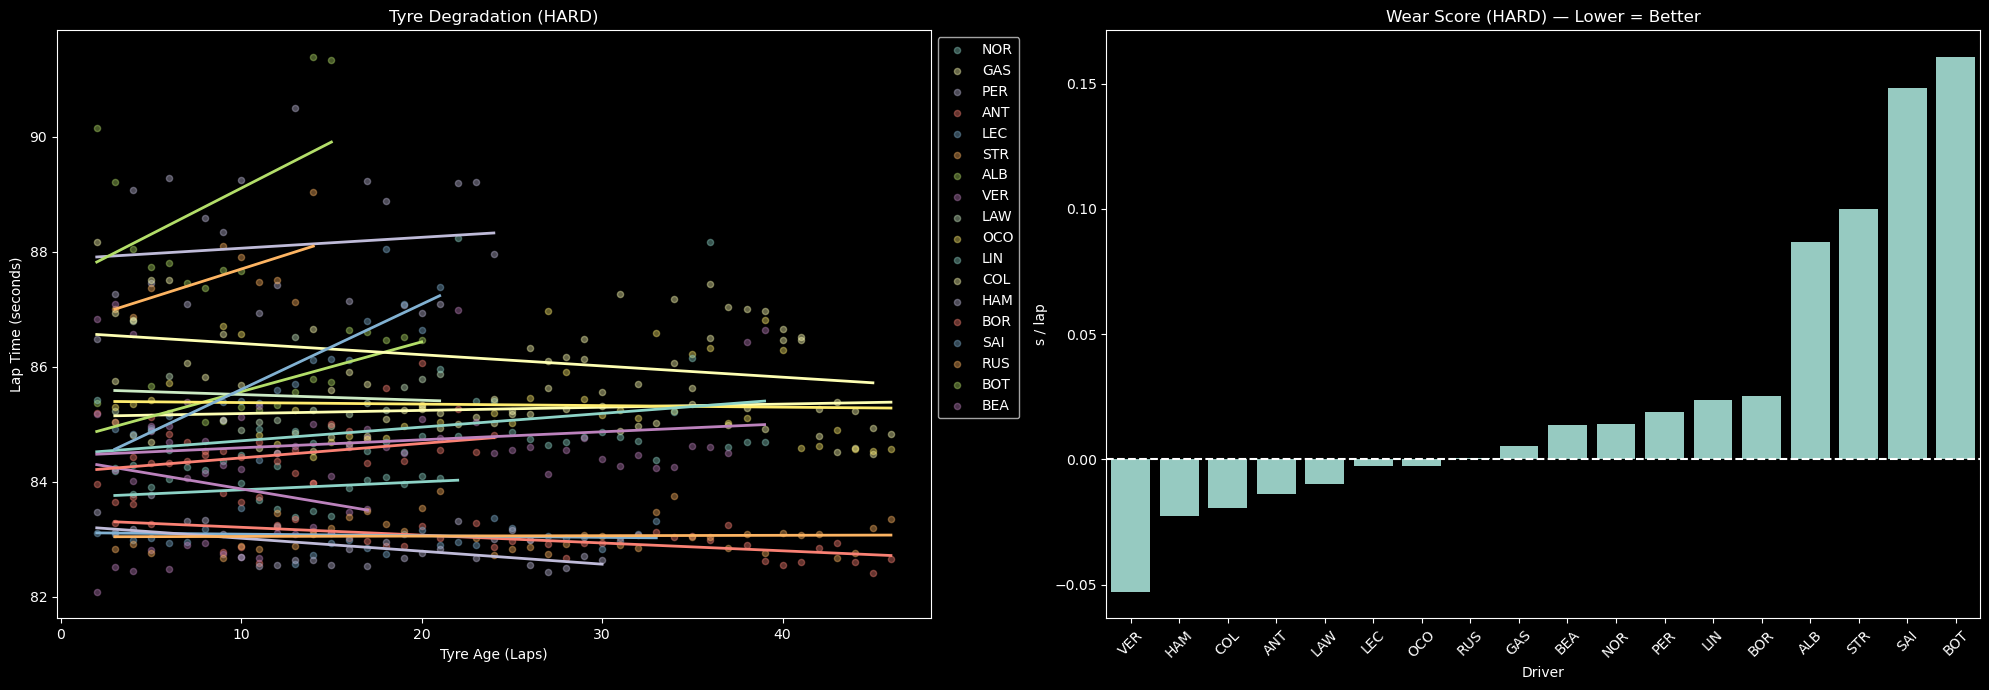

<Figure size 640x480 with 0 Axes>

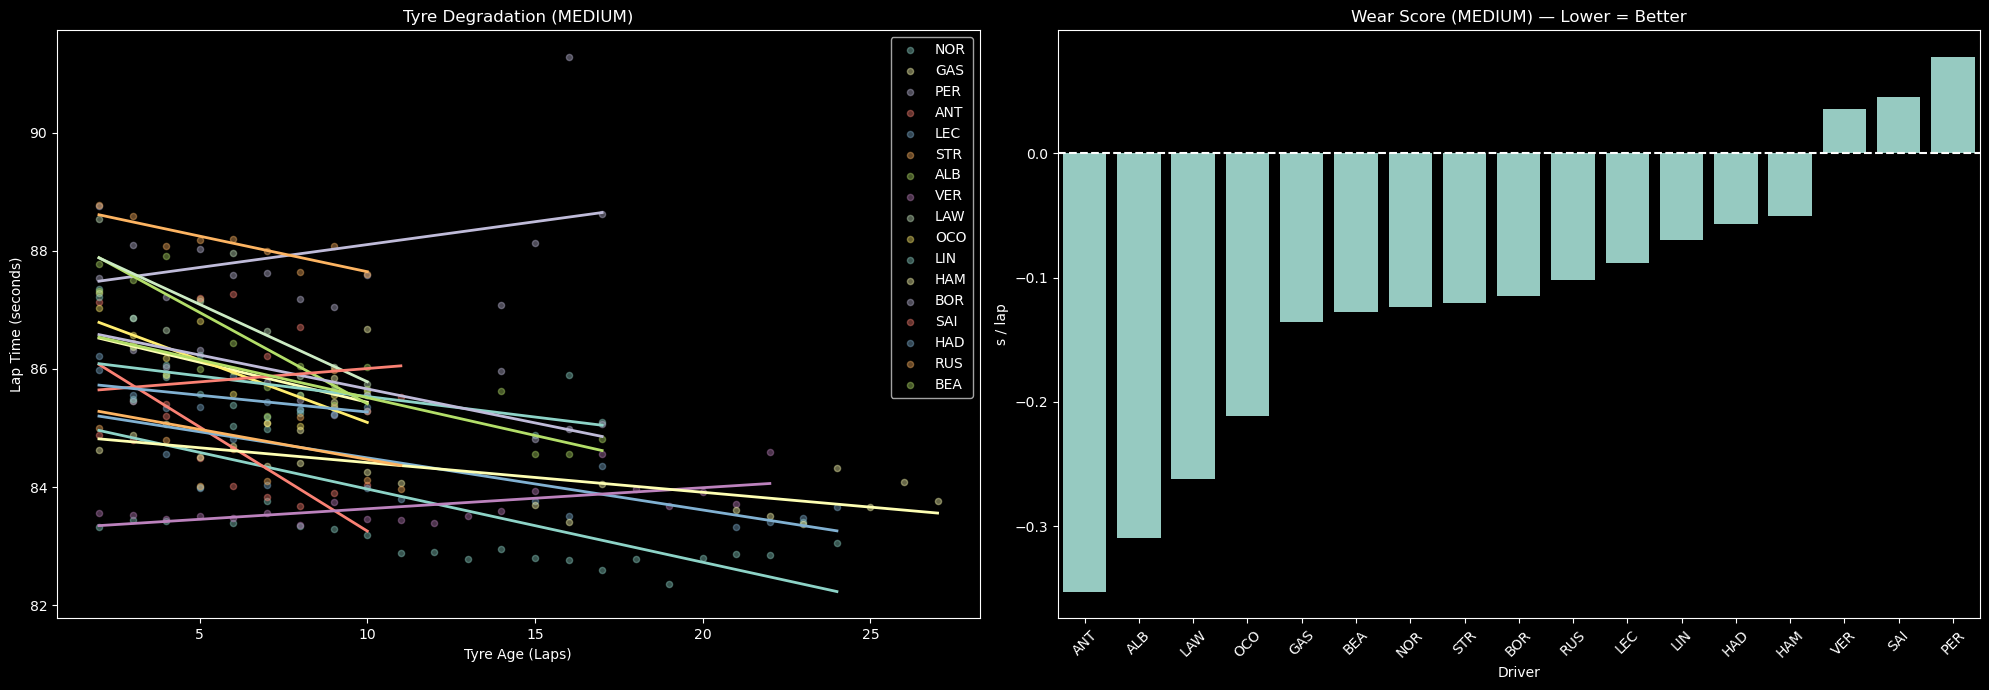

<Figure size 640x480 with 0 Axes>

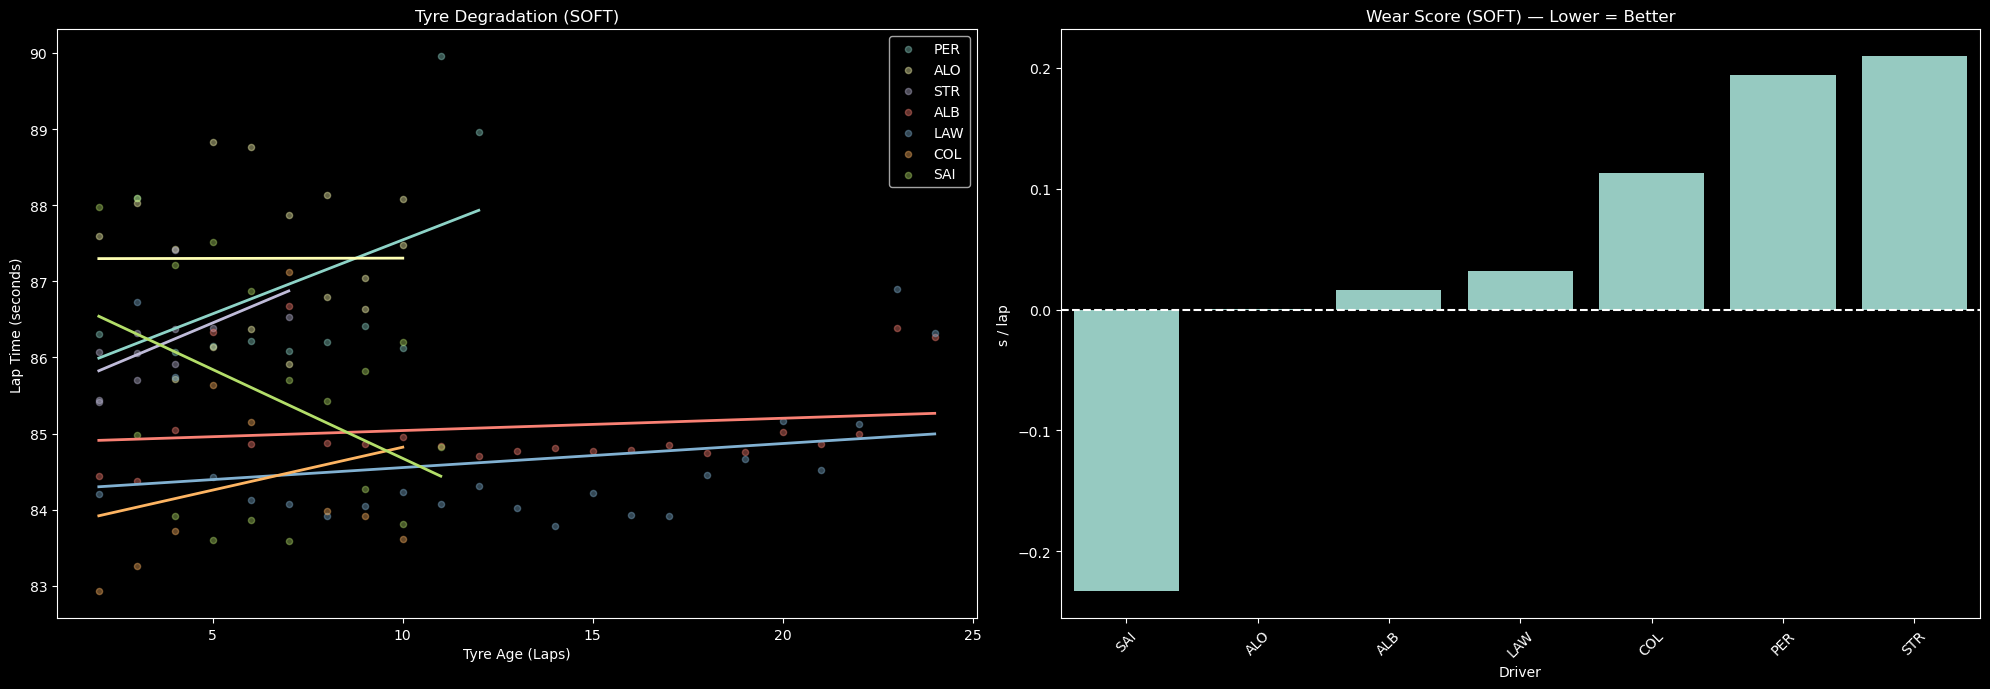

<Figure size 640x480 with 0 Axes>

In [243]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

compounds = ['HARD', 'MEDIUM', 'SOFT']

for compound in compounds:

    
    data = laps_filtered[
        (laps_filtered['Compound'] == compound) &
        (laps_filtered['LapTimeSeconds'].notna())
    ]

    # -------------------------
    # STEP 2 — Calculate Wear Score
    # -------------------------
    wear_list = []

    for driver in data['Driver'].unique():
        d = data[data['Driver'] == driver]
        
        if len(d) > 5:
            slope = np.polyfit(d['TyreLife'], d['LapTimeSeconds'], 1)[0]
            
            wear_list.append({
                'Driver': driver,
                'WearScore': slope
            })

    wear = pd.DataFrame(wear_list)
    wear = wear.sort_values('WearScore')


    fig, axes = plt.subplots(1, 2, figsize=(20,7))

    # LEFT → Degradation
    for d in data['Driver'].unique():
        d_data = data[data['Driver'] == d]
        
        sns.regplot(
            data=d_data,
            x='TyreLife',
            y='LapTimeSeconds',
            ax=axes[0],
            scatter=True,
            ci=None,
            label=d,
            scatter_kws={'alpha':0.4, 's':20},
            line_kws={'linewidth':2}
        )

    axes[0].set_title(f"Tyre Degradation ({compound})")
    axes[0].set_xlabel("Tyre Age (Laps)")
    axes[0].set_ylabel("Lap Time (seconds)")
    axes[0].legend(bbox_to_anchor=(1,1))

    # RIGHT → Wear Score
    sns.barplot(
        data=wear,
        x='Driver',
        y='WearScore',
        ax=axes[1]
    )

    axes[1].axhline(0, color='white', linestyle='--')
    axes[1].set_title(f"Wear Score ({compound}) — Lower = Better")
    axes[1].set_xlabel("Driver")
    axes[1].set_ylabel("s / lap")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    plt.savefig('../outputs/tyre_degradation.png')

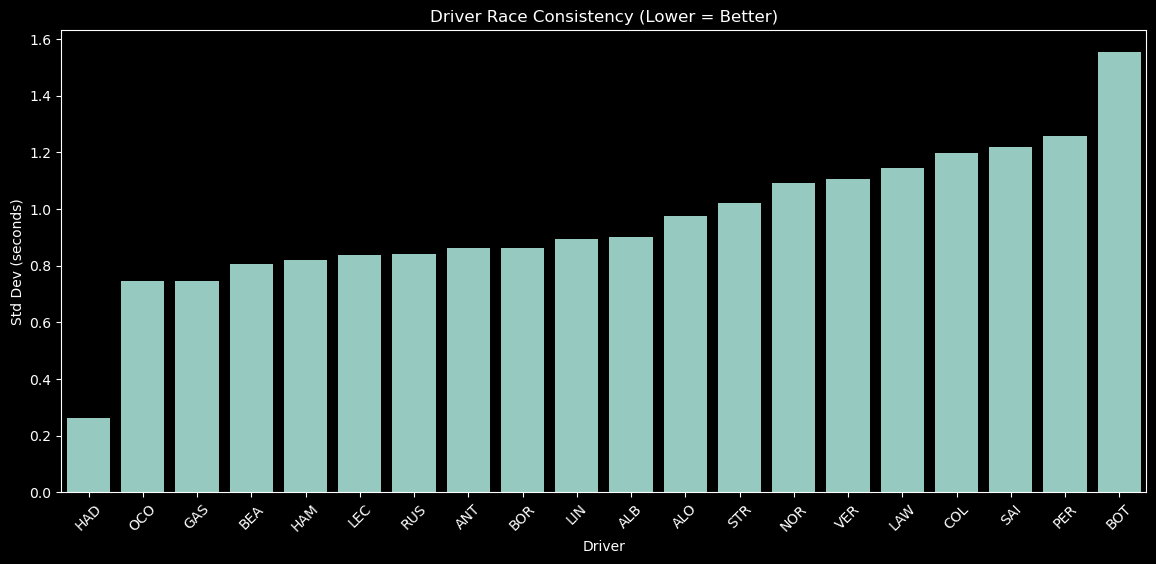

<Figure size 640x480 with 0 Axes>

In [241]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')


consistency_data = laps_filtered[
    laps_filtered['LapTimeSeconds'].notna()
]


consistency = consistency_data.groupby('Driver')['LapTimeSeconds'].std().reset_index()

consistency.columns = ['Driver', 'Consistency']


consistency = consistency.sort_values('Consistency')


plt.figure(figsize=(14,6))

sns.barplot(
    data=consistency,
    x='Driver',
    y='Consistency'
)

plt.title("Driver Race Consistency (Lower = Better)")
plt.xlabel("Driver")
plt.ylabel("Std Dev (seconds)")

plt.xticks(rotation=45)

plt.show()
plt.savefig('../outputs/driver_consistency.png')

In [113]:
laps_traffic = laps_filtered.copy()

laps_traffic['MedianPace'] = laps_traffic.groupby('Driver')['LapTimeSeconds'].transform('median')

In [115]:
laps_traffic['Traffic'] = laps_traffic['LapTimeSeconds'] > (laps_traffic['MedianPace'] + 1)

In [117]:
traffic_count = laps_traffic.groupby('Driver')['Traffic'].sum().reset_index()
traffic_count = traffic_count.rename(columns={'Traffic': 'TrafficLaps'})

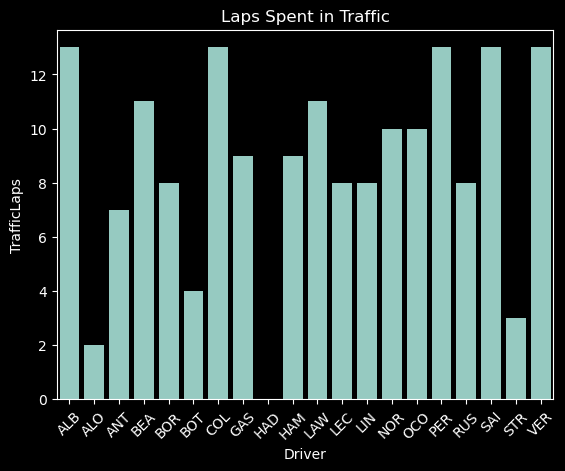

<Figure size 640x480 with 0 Axes>

In [239]:

sns.barplot(
    data=traffic_count,
    x='Driver',
    y='TrafficLaps'
)

plt.title("Laps Spent in Traffic")
plt.xticks(rotation=45)
plt.show()
plt.savefig('../outputs/traffic_analysis.png')

In [121]:
laps=20

In [123]:
drivers = ['VER', 'NOR']

In [127]:
laps_selected = session.laps[session.laps['LapNumber'] == laps]

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


NameError: name 'lap_num' is not defined

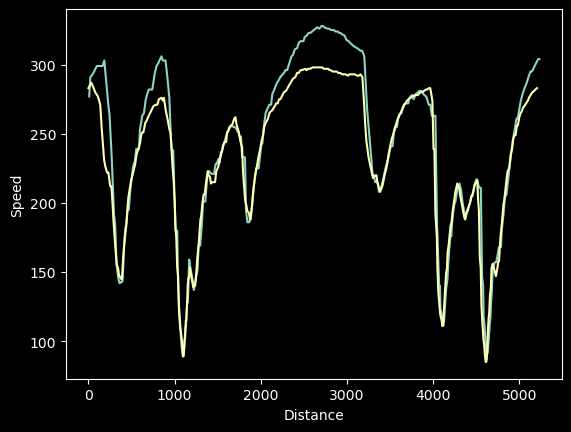

In [129]:
import matplotlib.pyplot as plt

for d in drivers:
    lap = laps_selected.pick_driver(d).iloc[0]
    tel = lap.get_car_data().add_distance()
    
    plt.plot(tel['Distance'], tel['Speed'], label=d)

plt.xlabel("Distance")
plt.ylabel("Speed")
plt.title(f"Speed Comparison - Lap {lap_num}")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


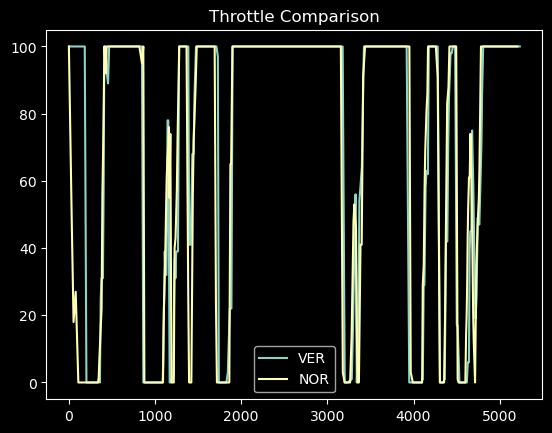

In [131]:
for d in drivers:
    lap = laps_selected.pick_driver(d).iloc[0]
    tel = lap.get_car_data().add_distance()
    
    plt.plot(tel['Distance'], tel['Throttle'], label=d)

plt.title("Throttle Comparison")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


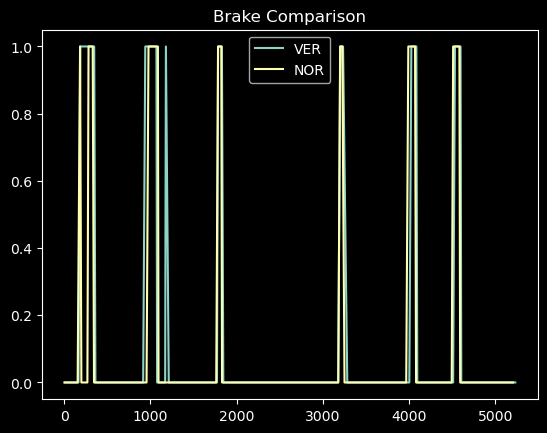

In [133]:
for d in drivers:
    lap = laps_selected.pick_driver(d).iloc[0]
    tel = lap.get_car_data().add_distance()
    
    plt.plot(tel['Distance'], tel['Brake'], label=d)

plt.title("Brake Comparison")
plt.legend()
plt.show()

In [135]:
lap = session.laps.pick_driver('VER').pick_fastest()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [137]:
tel = lap.get_car_data().add_distance()

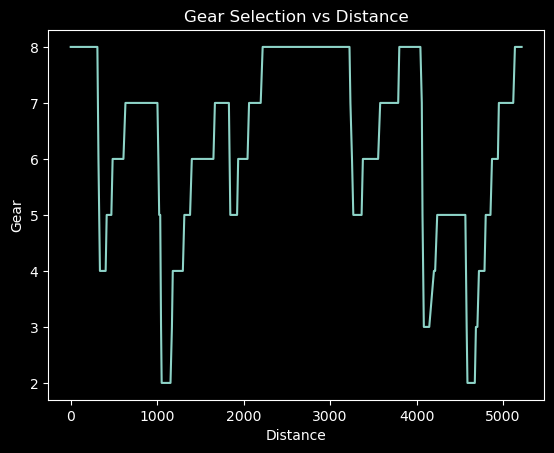

In [139]:
import matplotlib.pyplot as plt

plt.plot(tel['Distance'], tel['nGear'])

plt.xlabel("Distance")
plt.ylabel("Gear")
plt.title("Gear Selection vs Distance")

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


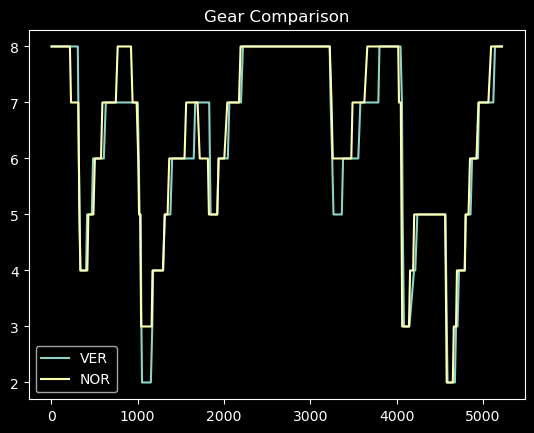

In [141]:
lap1 = session.laps.pick_driver('VER').pick_fastest()
lap2 = session.laps.pick_driver('NOR').pick_fastest()

tel1 = lap1.get_car_data().add_distance()
tel2 = lap2.get_car_data().add_distance()

plt.plot(tel1['Distance'], tel1['nGear'], label='VER')
plt.plot(tel2['Distance'], tel2['nGear'], label='NOR')

plt.legend()
plt.title("Gear Comparison")
plt.show()

In [143]:
lap = session.laps.pick_driver('VER').pick_fastest()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [145]:
tel = lap.get_car_data().add_distance()

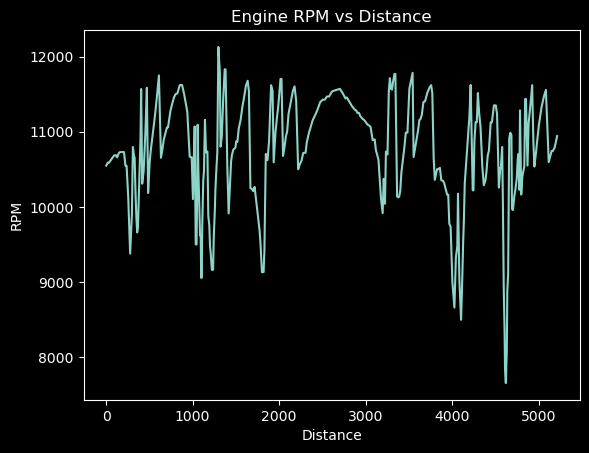

In [147]:
import matplotlib.pyplot as plt

plt.plot(tel['Distance'], tel['RPM'])

plt.xlabel("Distance")
plt.ylabel("RPM")
plt.title("Engine RPM vs Distance")

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


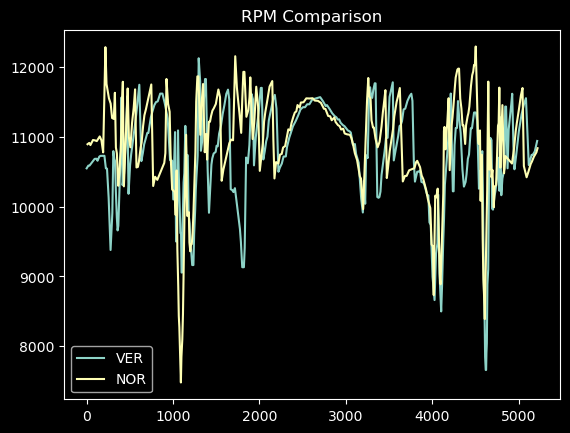

In [149]:
lap1 = session.laps.pick_driver('VER').pick_fastest()
lap2 = session.laps.pick_driver('NOR').pick_fastest()

tel1 = lap1.get_car_data().add_distance()
tel2 = lap2.get_car_data().add_distance()

plt.plot(tel1['Distance'], tel1['RPM'], label='VER')
plt.plot(tel2['Distance'], tel2['RPM'], label='NOR')

plt.legend()
plt.title("RPM Comparison")
plt.show()

In [151]:
laps_ham = laps_filtered.pick_driver('HAM')

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [153]:
fast_lap = laps_ham.pick_fastest()

In [155]:
slow_lap = laps_ham.sort_values('LapTimeSeconds', ascending=False).iloc[0]

In [157]:
print("Fast Lap:", fast_lap['LapNumber'], fast_lap['LapTime'])
print("Slow Lap:", slow_lap['LapNumber'], slow_lap['LapTime'])

Fast Lap: 55.0 0 days 00:01:22.423000
Slow Lap: 9.0 0 days 00:01:25.844000


In [159]:
tel_fast = fast_lap.get_car_data().add_distance()
tel_slow = slow_lap.get_car_data().add_distance()

In [161]:
import numpy as np

min_dist = max(tel_fast['Distance'].min(), tel_slow['Distance'].min())
max_dist = min(tel_fast['Distance'].max(), tel_slow['Distance'].max())

distance = np.linspace(min_dist, max_dist, 1000)

tel_fast = tel_fast.set_index('Distance').sort_index()
tel_fast = tel_fast.reindex(distance).interpolate()

tel_slow = tel_slow.set_index('Distance').sort_index()
tel_slow = tel_slow.reindex(distance).interpolate()

/var/folders/z8/mp0v8hgn3xl48dkmxkbj5s1m0000gn/T/ipykernel_47999/3164879292.py:9: FutureWarning: Telemetry.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  tel_fast = tel_fast.reindex(distance).interpolate()
/var/folders/z8/mp0v8hgn3xl48dkmxkbj5s1m0000gn/T/ipykernel_47999/3164879292.py:12: FutureWarning: Telemetry.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  tel_slow = tel_slow.reindex(distance).interpolate()


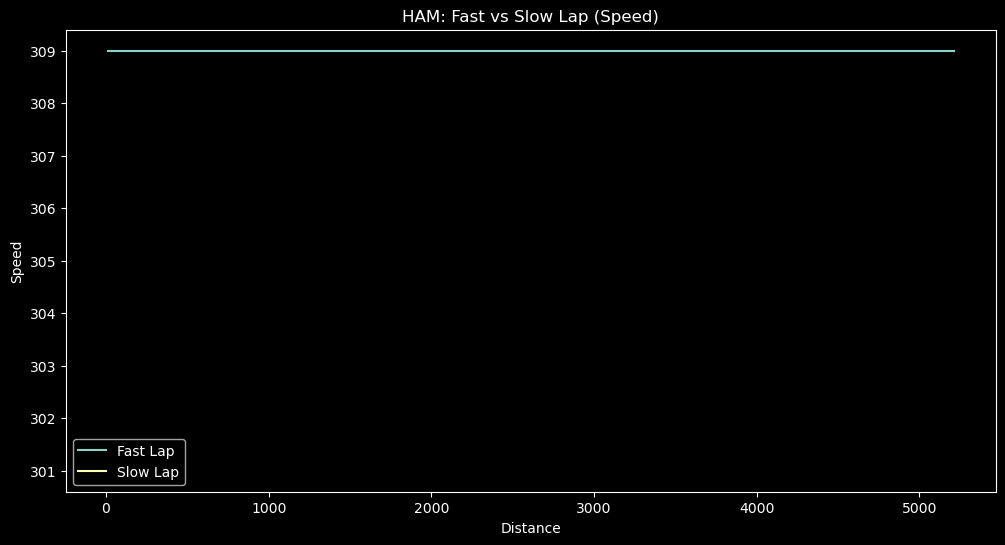

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(distance, tel_fast['Speed'], label='Fast Lap')
plt.plot(distance, tel_slow['Speed'], label='Slow Lap')

plt.xlabel("Distance")
plt.ylabel("Speed")
plt.title("HAM: Fast vs Slow Lap (Speed)")
plt.legend()

plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

Fast Lap: 55.0 0 days 00:01:22.423000
Slow Lap: 2.0 0 days 00:01:24.626000


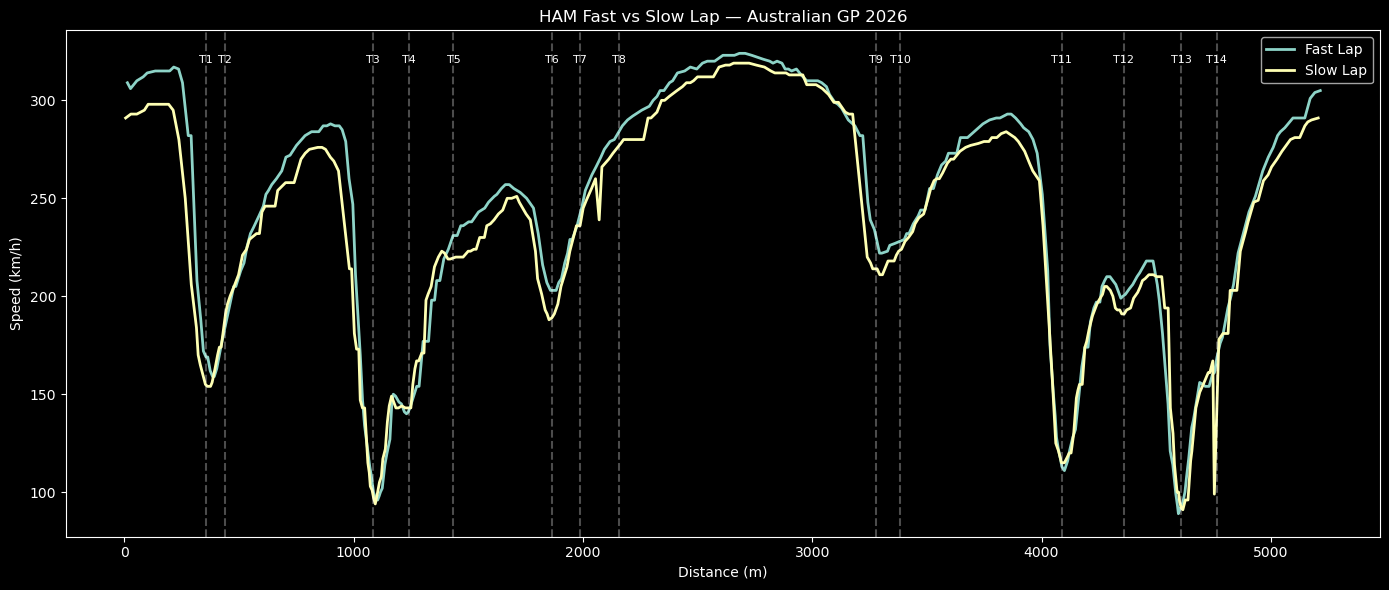

<Figure size 640x480 with 0 Axes>

In [237]:
import fastf1
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('.')  # safe cache

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

laps = session.laps.pick_driver('HAM').pick_quicklaps()

# pick fast + reasonable slow lap
fast_lap = laps.pick_fastest()
slow_lap = laps.sort_values('LapTime').iloc[-5]

print("Fast Lap:", fast_lap['LapNumber'], fast_lap['LapTime'])
print("Slow Lap:", slow_lap['LapNumber'], slow_lap['LapTime'])

tel_fast = fast_lap.get_car_data().add_distance()
tel_slow = slow_lap.get_car_data().add_distance()

circuit_info = session.get_circuit_info()
corners = circuit_info.corners

plt.figure(figsize=(14,6))

plt.plot(tel_fast['Distance'], tel_fast['Speed'], label='Fast Lap', linewidth=2)
plt.plot(tel_slow['Distance'], tel_slow['Speed'], label='Slow Lap', linewidth=2)


for _, corner in corners.iterrows():
    plt.axvline(x=corner['Distance'], linestyle='--', alpha=0.3)
    plt.text(
        corner['Distance'],
        plt.ylim()[1]*0.95,
        f"T{int(corner['Number'])}",
        ha='center',
        fontsize=8
    )

plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.title("HAM Fast vs Slow Lap — Australian GP 2026")
plt.legend()

plt.tight_layout()
plt.show()
plt.savefig('../outputs/ham_fast_vs_slow_speed.png')

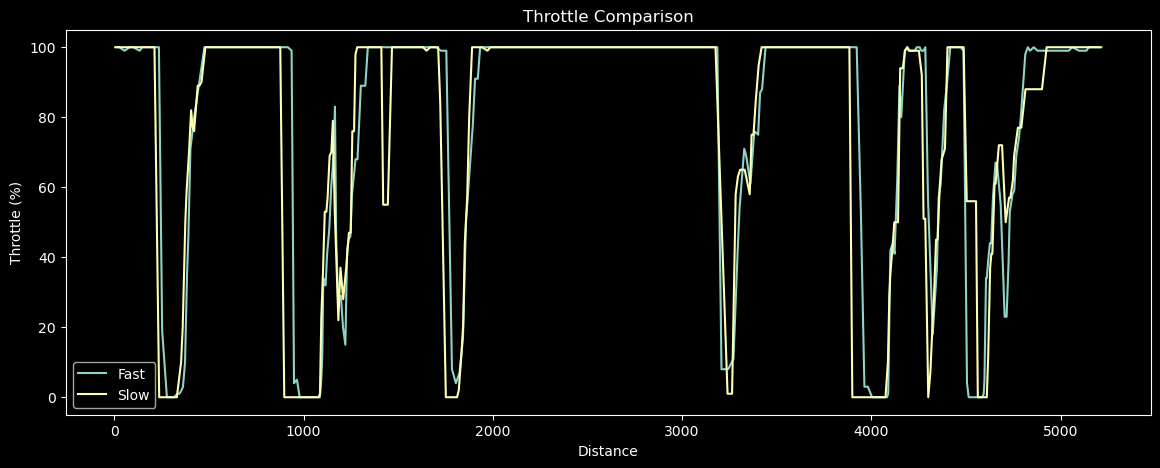

In [235]:
plt.figure(figsize=(14,5))

plt.plot(tel_fast['Distance'], tel_fast['Throttle'], label='Fast')
plt.plot(tel_slow['Distance'], tel_slow['Throttle'], label='Slow')

plt.title("Throttle Comparison")
plt.xlabel("Distance")
plt.ylabel("Throttle (%)")
plt.legend()

plt.show
plt.savefig('../outputs/rhamthrottle.png')

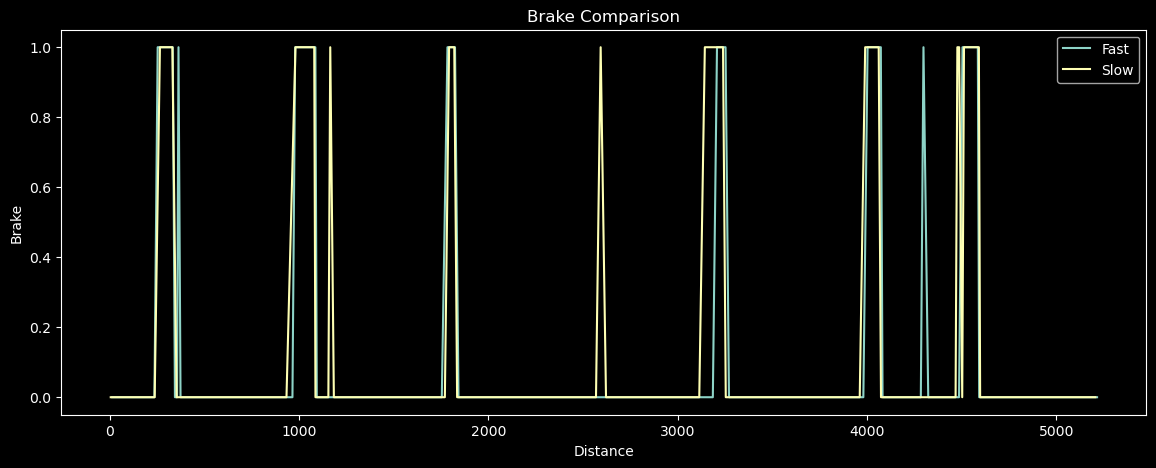

<Figure size 640x480 with 0 Axes>

In [233]:
plt.figure(figsize=(14,5))

plt.plot(tel_fast['Distance'], tel_fast['Brake'], label='Fast')
plt.plot(tel_slow['Distance'], tel_slow['Brake'], label='Slow')

plt.title("Brake Comparison")
plt.xlabel("Distance")
plt.ylabel("Brake")
plt.legend()

plt.show()
plt.savefig('../outputs/rhambrake.png')

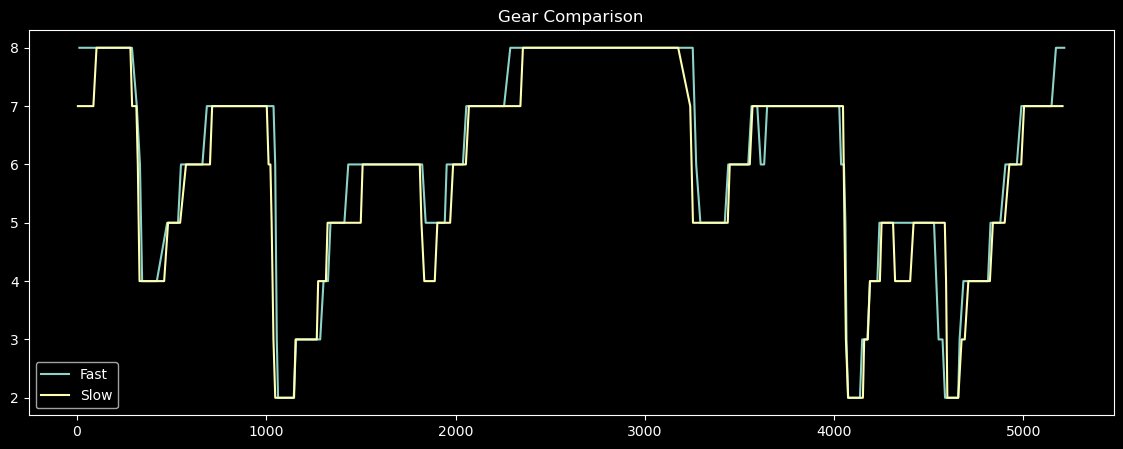

In [231]:
plt.figure(figsize=(14,5))

plt.plot(tel_fast['Distance'], tel_fast['nGear'], label='Fast')
plt.plot(tel_slow['Distance'], tel_slow['nGear'], label='Slow')

plt.title("Gear Comparison")
plt.legend()

plt.show
plt.savefig('../outputs/rham_gear.png')

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

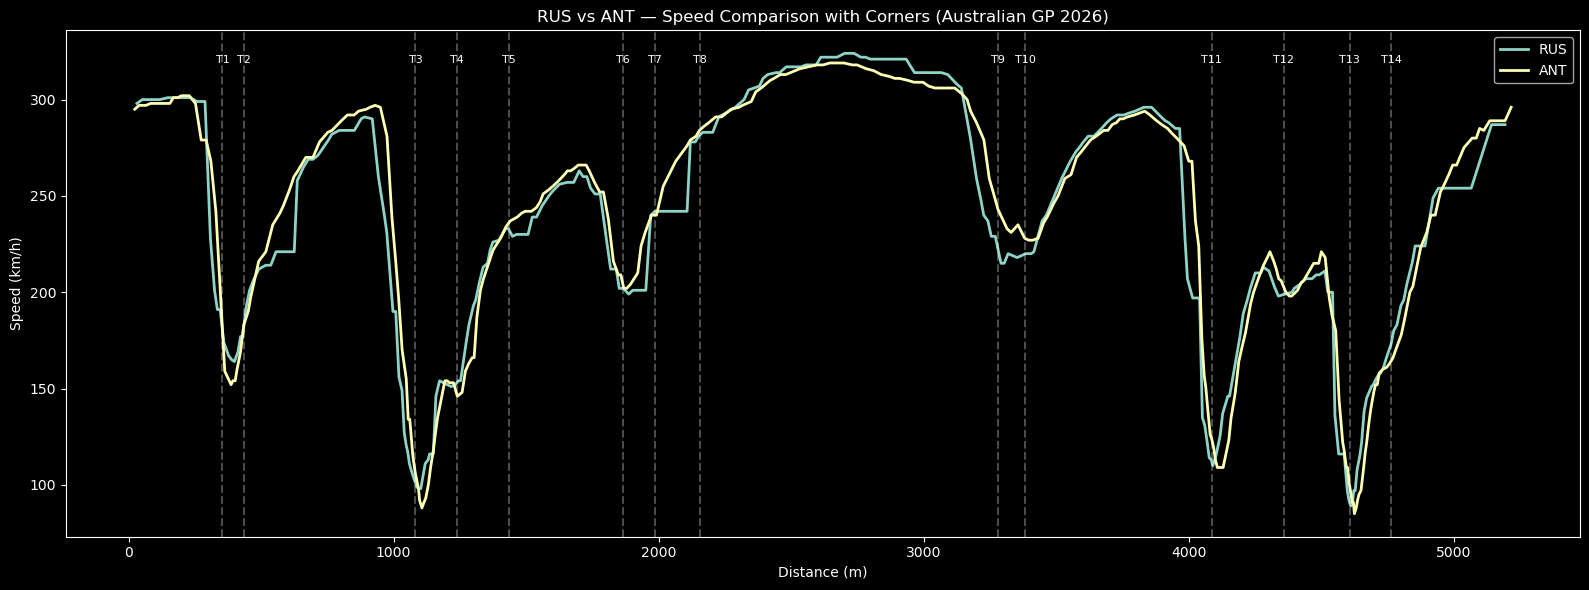

In [229]:
import fastf1
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

lap_rus = session.laps.pick_driver('RUS').pick_fastest()
lap_ant = session.laps.pick_driver('ANT').pick_fastest()

tel_rus = lap_rus.get_car_data().add_distance()
tel_ant = lap_ant.get_car_data().add_distance()

circuit_info = session.get_circuit_info()
corners = circuit_info.corners

plt.figure(figsize=(16,6))

plt.plot(tel_rus['Distance'], tel_rus['Speed'], label='RUS', linewidth=2)
plt.plot(tel_ant['Distance'], tel_ant['Speed'], label='ANT', linewidth=2)

for _, corner in corners.iterrows():
    dist = corner['Distance']
    number = int(corner['Number'])

    # vertical line
    plt.axvline(x=dist, linestyle='--', alpha=0.3)

    # label
    plt.text(
        dist,
        plt.ylim()[1]*0.95,
        f"T{number}",
        ha='center',
        fontsize=8
    )

plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.title("RUS vs ANT — Speed Comparison with Corners (Australian GP 2026)")
plt.legend()

plt.tight_layout()
plt.show
plt.savefig('../outputs/rus_vs_ant_speed.png')

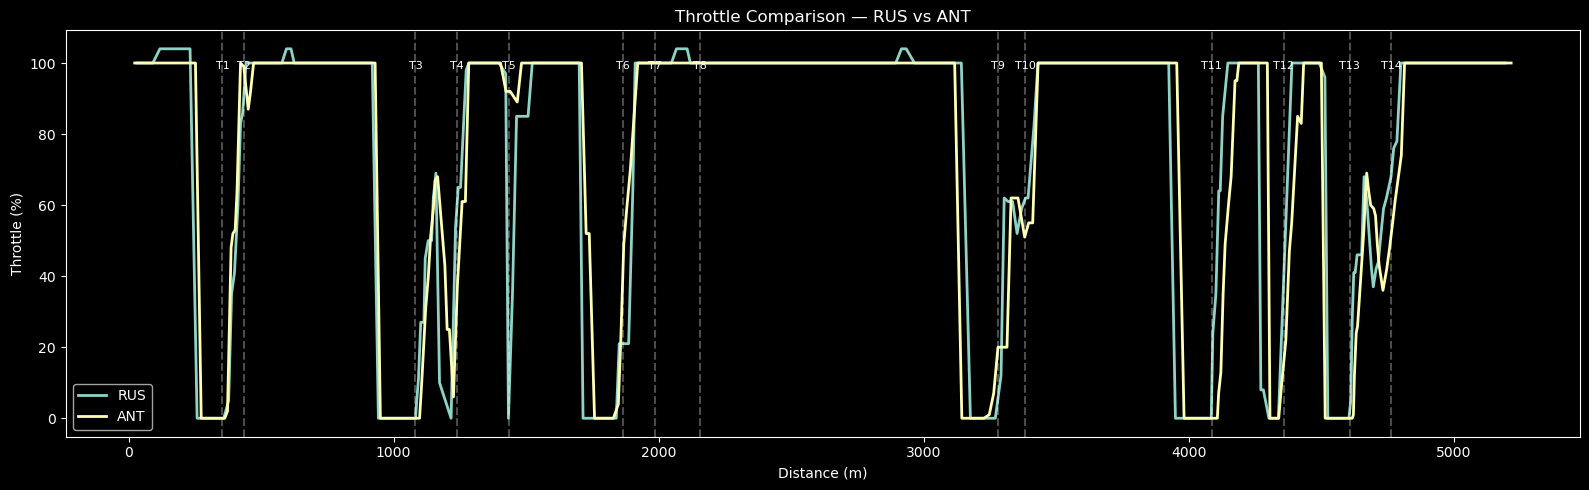

In [227]:
plt.figure(figsize=(16,5))

plt.plot(tel_rus['Distance'], tel_rus['Throttle'], label='RUS', linewidth=2)
plt.plot(tel_ant['Distance'], tel_ant['Throttle'], label='ANT', linewidth=2)

for _, corner in corners.iterrows():
    dist = corner['Distance']
    num = int(corner['Number'])
    plt.axvline(x=dist, linestyle='--', alpha=0.3)
    plt.text(dist, plt.ylim()[1]*0.9, f"T{num}", ha='center', fontsize=8)

plt.xlabel("Distance (m)")
plt.ylabel("Throttle (%)")
plt.title("Throttle Comparison — RUS vs ANT")
plt.legend()
plt.tight_layout()
plt.show
plt.savefig('../outputs/rus_vs_ant_throttle.png')

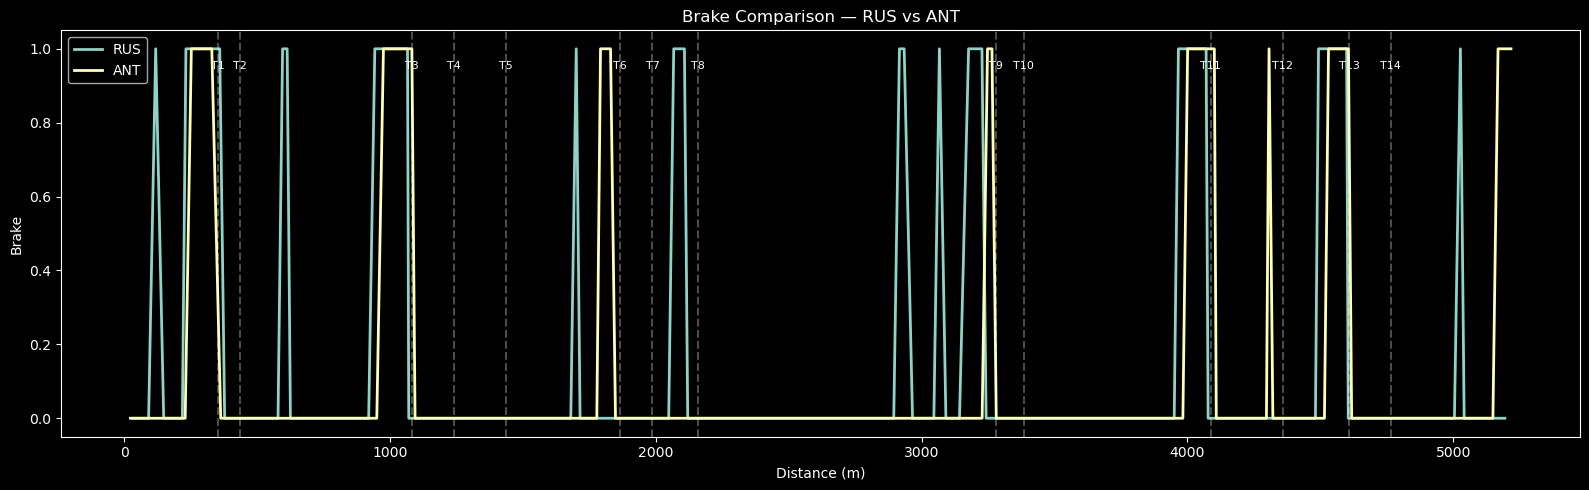

In [225]:
plt.figure(figsize=(16,5))

plt.plot(tel_rus['Distance'], tel_rus['Brake'], label='RUS', linewidth=2)
plt.plot(tel_ant['Distance'], tel_ant['Brake'], label='ANT', linewidth=2)

for _, corner in corners.iterrows():
    dist = corner['Distance']
    num = int(corner['Number'])
    plt.axvline(x=dist, linestyle='--', alpha=0.3)
    plt.text(dist, plt.ylim()[1]*0.9, f"T{num}", ha='center', fontsize=8)

plt.xlabel("Distance (m)")
plt.ylabel("Brake")
plt.title("Brake Comparison — RUS vs ANT")
plt.legend()
plt.tight_layout()
plt.show
plt.savefig('../outputs/rus_vs_ant_brake.png')

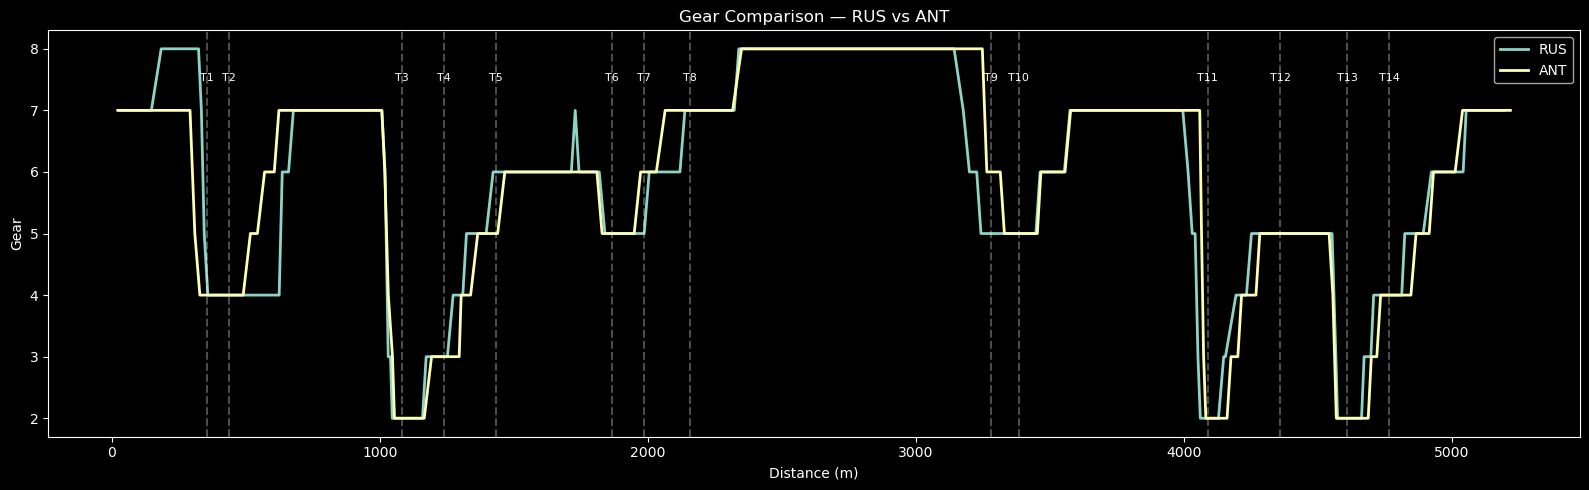

<Figure size 640x480 with 0 Axes>

In [223]:
plt.figure(figsize=(16,5))

plt.plot(tel_rus['Distance'], tel_rus['nGear'], label='RUS', linewidth=2)
plt.plot(tel_ant['Distance'], tel_ant['nGear'], label='ANT', linewidth=2)

for _, corner in corners.iterrows():
    dist = corner['Distance']
    num = int(corner['Number'])
    plt.axvline(x=dist, linestyle='--', alpha=0.3)
    plt.text(dist, plt.ylim()[1]*0.9, f"T{num}", ha='center', fontsize=8)

plt.xlabel("Distance (m)")
plt.ylabel("Gear")
plt.title("Gear Comparison — RUS vs ANT")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('../outputs/rus_vs_ant_gear.png')

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

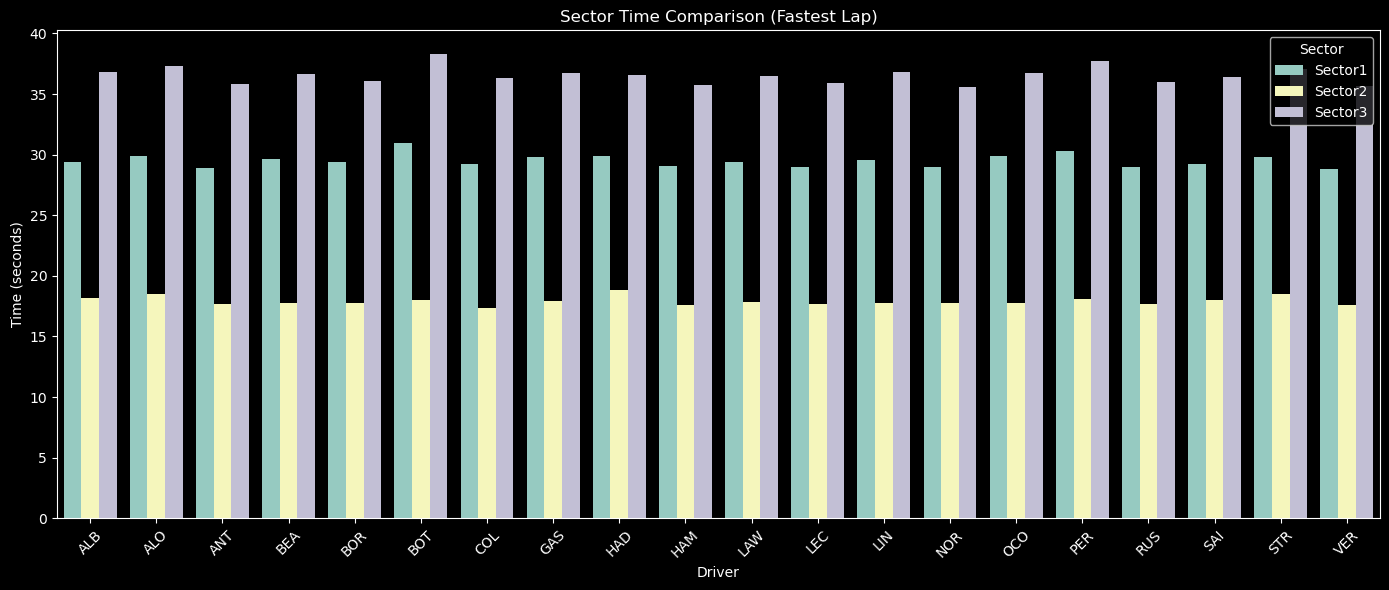

In [221]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

llaps = session.laps.pick_quicklaps()

fastest_laps = laps.groupby('Driver', group_keys=False).apply(lambda x: x.pick_fastest())

sector_data = fastest_laps[['Driver', 'Sector1Time', 'Sector2Time', 'Sector3Time']].copy()

sector_data['Sector1'] = sector_data['Sector1Time'].dt.total_seconds()
sector_data['Sector2'] = sector_data['Sector2Time'].dt.total_seconds()
sector_data['Sector3'] = sector_data['Sector3Time'].dt.total_seconds()
sector_data = sector_data[['Driver', 'Sector1', 'Sector2', 'Sector3']]

sector_melted = sector_data.melt(id_vars='Driver',
                                 value_vars=['Sector1','Sector2','Sector3'],
                                 var_name='Sector',
                                 value_name='Time')


plt.figure(figsize=(14,6))

sns.barplot(
    data=sector_melted,
    x='Driver',
    y='Time',
    hue='Sector'
)

plt.title("Sector Time Comparison (Fastest Lap)")
plt.xlabel("Driver")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)

plt.legend(title="Sector")
plt.tight_layout()
plt.show
plt.savefig('../outputs/sector_time_comparison.png')

In [189]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

laps = session.laps.pick_quicklaps()

fastest_laps = laps.groupby('Driver', group_keys=False).apply(lambda x: x.pick_fastest())

data = fastest_laps[['Driver', 'Team', 'SpeedST']].copy()

# Mean Speed calculation
data['MeanSpeed'] = fastest_laps['Speed'].groupby(fastest_laps['Team']).transform('mean')

team_perf = data.groupby('Team').agg({
    'SpeedST': 'max',      # Top Speed
    'MeanSpeed': 'mean'    # Avg Speed
}).reset_index()

team_perf.columns = ['Team', 'TopSpeed', 'MeanSpeed']

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=team_perf,
    x='MeanSpeed',
    y='TopSpeed',
    s=100
)

# Add labels
for i in range(len(team_perf)):
    plt.text(
        team_perf['MeanSpeed'][i],
        team_perf['TopSpeed'][i],
        team_perf['Team'][i],
        fontsize=9
    )

plt.xlabel("Mean Speed (km/h)")
plt.ylabel("Top Speed (km/h)")
plt.title("Team Performance — Top Speed vs Mean Speed")

plt.grid(alpha=0.3)
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

KeyError: 'Speed'

In [191]:

fastest_laps = laps.groupby('Driver', group_keys=False).apply(lambda x: x.pick_fastest())

data = fastest_laps[['Driver', 'Team', 'SpeedST', 'LapTime']].copy()

# Convert LapTime to seconds
data['LapTimeSeconds'] = data['LapTime'].dt.total_seconds()

# Estimate mean speed (Track length approx = 5300m for Australia)
track_length_km = 5.3

data['MeanSpeed'] = (track_length_km / (data['LapTimeSeconds'] / 3600))


team_perf = data.groupby('Team').agg({
    'SpeedST': 'max',
    'MeanSpeed': 'mean'
}).reset_index()

team_perf.columns = ['Team', 'TopSpeed', 'MeanSpeed']

/var/folders/z8/mp0v8hgn3xl48dkmxkbj5s1m0000gn/T/ipykernel_47999/356528253.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fastest_laps = laps.groupby('Driver', group_keys=False).apply(lambda x: x.pick_fastest())


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

               Team  TopSpeed   MeanSpeed
0            Alpine     298.0  227.960444
1      Aston Martin     285.0  222.998192
2              Audi     290.0  229.169920
3          Cadillac     289.0  220.038311
4           Ferrari     316.0  231.270131
5      Haas F1 Team     304.0  226.545437
6           McLaren     288.0  231.671483
7          Mercedes     301.0  231.151391
8      Racing Bulls     296.0  227.191470
9   Red Bull Racing     297.0  228.133096
10         Williams     289.0  227.195151


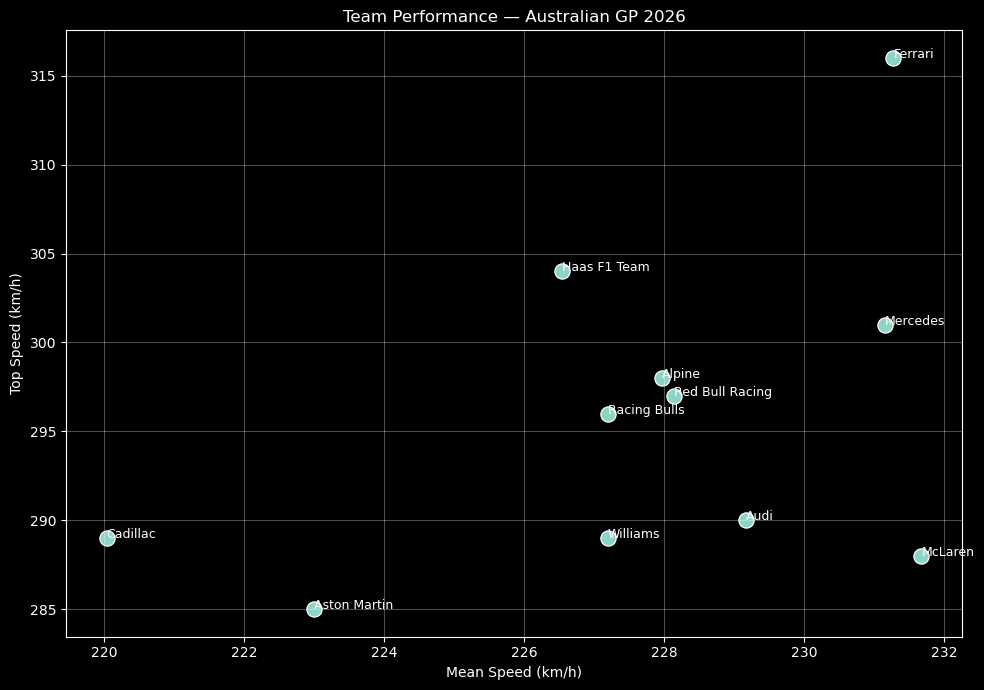

In [219]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

laps = session.laps.pick_quicklaps()

fastest_laps = laps.loc[laps.groupby('Driver')['LapTime'].idxmin()]

data = fastest_laps[['Driver', 'Team', 'SpeedST', 'LapTime']].copy()

data['LapTimeSeconds'] = data['LapTime'].dt.total_seconds()

track_length_km = 5.3

data['MeanSpeed'] = track_length_km / (data['LapTimeSeconds'] / 3600)

team_perf = data.groupby('Team').agg({
    'SpeedST': 'max',      # Top Speed
    'MeanSpeed': 'mean'    # Average Speed
}).reset_index()

team_perf.columns = ['Team', 'TopSpeed', 'MeanSpeed']

print(team_perf)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=team_perf,
    x='MeanSpeed',
    y='TopSpeed',
    s=120
)

# Add labels
for i in range(len(team_perf)):
    plt.text(
        team_perf['MeanSpeed'][i],
        team_perf['TopSpeed'][i],
        team_perf['Team'][i],
        fontsize=9
    )

plt.xlabel("Mean Speed (km/h)")
plt.ylabel("Top Speed (km/h)")
plt.title("Team Performance — Australian GP 2026")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show
plt.savefig('../outputs/team_performance_buble.png')

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

               Team  TopSpeed    AvgSpeed
0            Alpine     298.0  227.960444
1      Aston Martin     285.0  222.998192
2              Audi     290.0  229.169920
3          Cadillac     289.0  220.038311
4           Ferrari     316.0  231.270131
5      Haas F1 Team     304.0  226.545437
6           McLaren     288.0  231.671483
7          Mercedes     301.0  231.151391
8      Racing Bulls     296.0  227.191470
9   Red Bull Racing     297.0  228.133096
10         Williams     289.0  227.195151


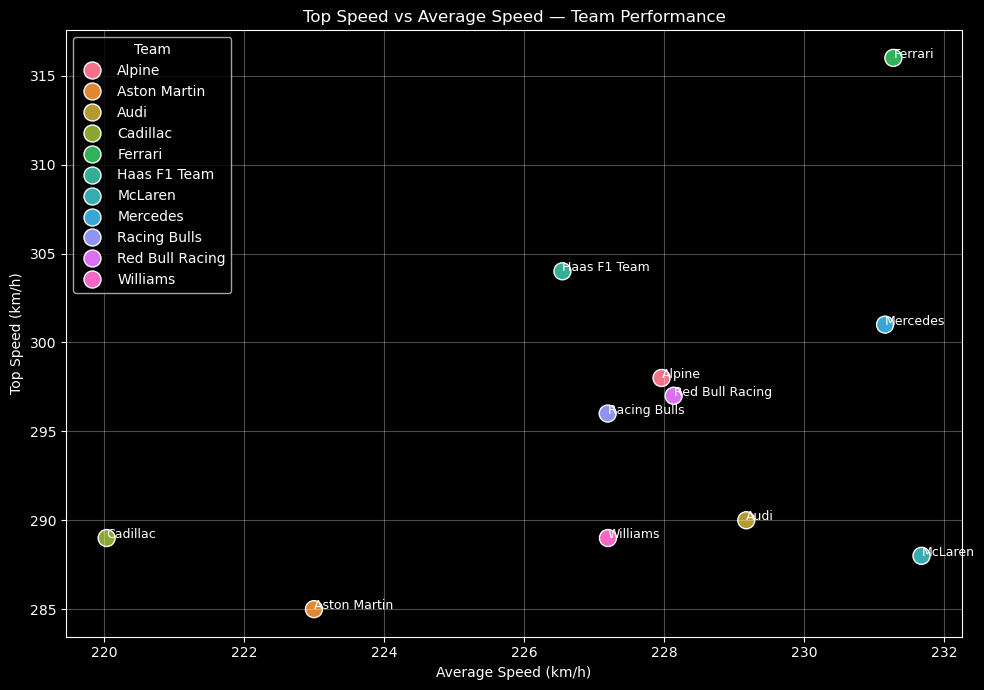

<Figure size 640x480 with 0 Axes>

In [217]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

laps = session.laps.pick_quicklaps()


fastest_laps = laps.loc[laps.groupby('Driver')['LapTime'].idxmin()]

data = fastest_laps[['Driver', 'Team', 'SpeedST', 'LapTime']].copy()

data['LapTimeSeconds'] = data['LapTime'].dt.total_seconds()

track_length_km = 5.3


data['AvgSpeed'] = track_length_km / (data['LapTimeSeconds'] / 3600)

team_perf = data.groupby('Team').agg({
    'SpeedST': 'max',
    'AvgSpeed': 'mean'
}).reset_index()

team_perf.columns = ['Team', 'TopSpeed', 'AvgSpeed']

print(team_perf)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=team_perf,
    x='AvgSpeed',
    y='TopSpeed',
    hue='Team',
    s=150
)

# Add labels
for i in range(len(team_perf)):
    plt.text(
        team_perf['AvgSpeed'][i],
        team_perf['TopSpeed'][i],
        team_perf['Team'][i],
        fontsize=9
    )

plt.xlabel("Average Speed (km/h)")
plt.ylabel("Top Speed (km/h)")
plt.title("Top Speed vs Average Speed — Team Performance")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('../outputs/topvsavgggspeedbuble.png')

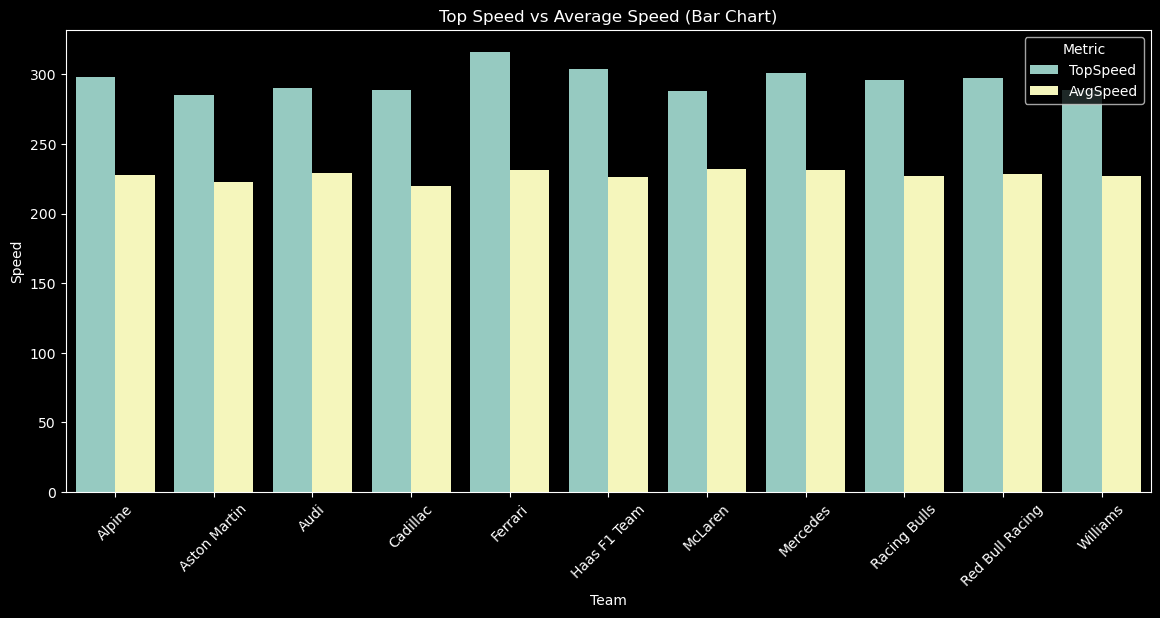

<Figure size 640x480 with 0 Axes>

In [215]:
team_melted = team_perf.melt(
    id_vars='Team',
    value_vars=['TopSpeed','AvgSpeed'],
    var_name='Metric',
    value_name='Speed'
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=team_melted,
    x='Team',
    y='Speed',
    hue='Metric'
)

plt.title("Top Speed vs Average Speed (Bar Chart)")
plt.xticks(rotation=45)

plt.show()
plt.savefig('../outputs/topvsavgspeed.png')

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1

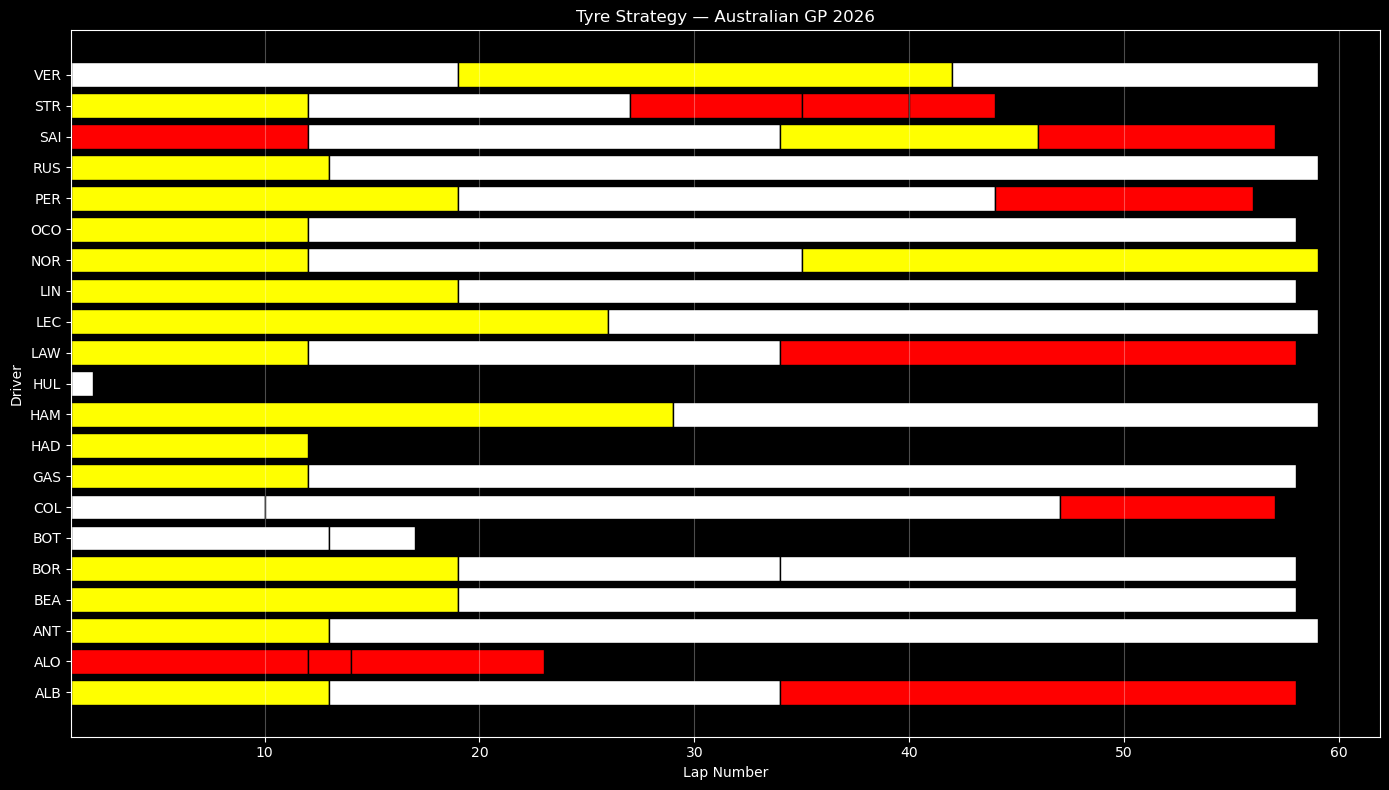

In [213]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('.')

session = fastf1.get_session(2026, 'Australian Grand Prix', 'R')
session.load()

laps = session.laps

stints = laps[['Driver', 'Stint', 'Compound', 'LapNumber']].copy()

stints = stints.groupby(['Driver', 'Stint', 'Compound']).agg({
    'LapNumber': ['min', 'max']
}).reset_index()

stints.columns = ['Driver', 'Stint', 'Compound', 'StartLap', 'EndLap']
stints['StintLength'] = stints['EndLap'] - stints['StartLap'] + 1

compound_colors = {
    'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white',
    'INTERMEDIATE': 'green',
    'WET': 'blue'
}

drivers = stints['Driver'].unique()

plt.figure(figsize=(14,8))

for i, driver in enumerate(drivers):
    driver_stints = stints[stints['Driver'] == driver]
    
    for _, row in driver_stints.iterrows():
        plt.barh(
            driver,
            row['StintLength'],
            left=row['StartLap'],
            color=compound_colors.get(row['Compound'], 'grey'),
            edgecolor='black'
        )

plt.xlabel("Lap Number")
plt.ylabel("Driver")
plt.title("Tyre Strategy — Australian GP 2026")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig('../outputs/tyre_strategy.png')

In [209]:
plt.savefig('../outputs/tyre_strategy.png')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/krithikarajan/F1-Data Analytics board/outputs/tyre_strategy.png'

<Figure size 640x480 with 0 Axes>

In [259]:
laps_filtered


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,CumulativeTime,GapToLeader
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,2026-03-08 04:05:03.060,1,6.0,False,,False,True,87.344,87.344,2.718
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,2026-03-08 04:06:30.404,1,7.0,False,,False,True,86.863,174.207,4.707
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,2026-03-08 04:07:57.267,1,7.0,False,,False,True,85.857,260.064,5.498
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,2026-03-08 04:09:23.124,1,7.0,False,,False,True,85.573,345.637,6.569
5,0 days 01:11:07.110000,NOR,1,0 days 00:01:25.036000,6.0,1.0,NaT,NaT,0 days 00:00:30.025000,0 days 00:00:17.829000,...,2026-03-08 04:10:48.697,1,7.0,False,,False,True,85.036,430.673,85.138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,0 days 02:19:49.241000,BEA,87,0 days 00:01:24.615000,53.0,2.0,NaT,NaT,0 days 00:00:29.699000,0 days 00:00:17.937000,...,2026-03-08 05:19:31.249,1,7.0,False,,False,True,84.615,3821.968,230.076
1003,0 days 02:21:13.851000,BEA,87,0 days 00:01:24.610000,54.0,2.0,NaT,NaT,0 days 00:00:29.965000,0 days 00:00:17.876000,...,2026-03-08 05:20:55.864,1,7.0,False,,False,True,84.610,3906.578,301.369
1004,0 days 02:22:38.351000,BEA,87,0 days 00:01:24.500000,55.0,2.0,NaT,NaT,0 days 00:00:29.725000,0 days 00:00:17.930000,...,2026-03-08 05:22:20.474,1,7.0,False,,False,True,84.500,3991.078,302.060
1005,0 days 02:24:04.790000,BEA,87,0 days 00:01:26.439000,56.0,2.0,NaT,NaT,0 days 00:00:29.768000,0 days 00:00:17.858000,...,2026-03-08 05:23:44.974,1,7.0,False,,False,True,86.439,4077.517,303.676


In [261]:
sector_data


,Driver,Sector1,Sector2,Sector3
Driver,,,,
ALB,ALB,29.418,18.165,36.792
ALO,ALO,29.879,18.494,37.340
ANT,ANT,28.926,17.660,35.831
BEA,BEA,29.612,17.740,36.668
BOR,BOR,29.395,17.800,36.062
BOT,BOT,30.990,18.033,38.341
COL,COL,29.194,17.380,36.352
GAS,GAS,29.844,17.894,36.748
HAD,HAD,29.867,18.795,36.577


In [263]:
team_perf

,Team,TopSpeed,MeanSpeed
0,Alpine,298.0,227.960444
1,Aston Martin,285.0,222.998192
2,Audi,290.0,229.169920
3,Cadillac,289.0,220.038311
4,Ferrari,316.0,231.270131
5,Haas F1 Team,304.0,226.545437
6,McLaren,288.0,231.671483
7,Mercedes,301.0,231.151391
8,Racing Bulls,296.0,227.191470
9,Red Bull Racing,297.0,228.133096


In [265]:
laps_filtered.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,CumulativeTime,GapToLeader
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,...,2026-03-08 04:05:03.060,1,6.0,False,,False,True,87.344,87.344,2.718
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,...,2026-03-08 04:06:30.404,1,7.0,False,,False,True,86.863,174.207,4.707
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,...,2026-03-08 04:07:57.267,1,7.0,False,,False,True,85.857,260.064,5.498
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,...,2026-03-08 04:09:23.124,1,7.0,False,,False,True,85.573,345.637,6.569
5,0 days 01:11:07.110000,NOR,1,0 days 00:01:25.036000,6.0,1.0,NaT,NaT,0 days 00:00:30.025000,0 days 00:00:17.829000,...,2026-03-08 04:10:48.697,1,7.0,False,,False,True,85.036,430.673,85.138


In [267]:
sector_data.head()

,Driver,Sector1,Sector2,Sector3
Driver,,,,
ALB,ALB,29.418,18.165,36.792
ALO,ALO,29.879,18.494,37.340
ANT,ANT,28.926,17.660,35.831
BEA,BEA,29.612,17.740,36.668
BOR,BOR,29.395,17.800,36.062


In [269]:
team_perf.head()

,Team,TopSpeed,MeanSpeed
0,Alpine,298.0,227.960444
1,Aston Martin,285.0,222.998192
2,Audi,290.0,229.169920
3,Cadillac,289.0,220.038311
4,Ferrari,316.0,231.270131


In [ ]:
# Export files for Power BI

# 1. Team performance
team_perf.to_csv('../data/team_performance.csv', index=False)

# 2. Sector data
sector_data.to_csv('../data/sector_data.csv', index=False)

# 3. Laps data
laps_filtered.to_csv('../data/laps_data.csv', index=False)

print("Files exported successfully!")